# Connecting to the DB

In [10]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

INITIAL_CAPITAL = 10_000
TRADING_DAYS_PER_YEAR = 252

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [11]:
from pathlib import Path
import sqlite3 as sql

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

db_path = ROOT / "database" / "logger" / "aroogula_core.db"

sql_query = """
SELECT *
FROM equity_log;
"""

with sql.connect(db_path) as conn:
    df = pd.read_sql(sql_query, conn)

print(df.head())

   id            timestamp        cash  portfolio_assets      equity  \
0   1  2026-07-28T07:07:49 10,000.0000            0.0000 10,000.0000   
1   2  2026-07-28T07:10:47 10,000.0000            0.0000 10,000.0000   
2   3  2026-07-28T07:15:48  9,814.8800          185.1200 10,000.0000   
3   4  2026-07-28T07:17:00  9,814.8800          185.1200 10,000.0000   
4   5  2026-07-28T07:18:01  9,814.8800          185.1200 10,000.0000   

   open_positions_count  daily_pnl  daily_pnl_pct  total_exposure_pct  \
0                     0     0.0000         0.0000              0.0000   
1                     0     0.0000         0.0000              0.0000   
2                     1     0.0000         0.0000              1.8512   
3                     1     0.0000         0.0000              1.8512   
4                     1     0.0000         0.0000              1.8512   

   max_position_weight_pct execution_mode           created_at  
0                   0.0000      local_sim  2026-07-28 13:07:49 

In [12]:
# Make a clean copy so we don't mutate the original dataframe
equity_df = df.copy()

equity_df["datetime_col"] = pd.to_datetime(equity_df["timestamp"])
equity_df["date"] = equity_df["datetime_col"].dt.date

# Only days where the bot actually had capital deployed
active_df = equity_df[equity_df["portfolio_assets"] > 0].copy()

daily_stats = (
    active_df
    .groupby("date")
    .agg(
        avg_deployed_capital=("portfolio_assets", "mean"),
        max_deployed_capital=("portfolio_assets", "max"),
        min_deployed_capital=("portfolio_assets", "min"),
        avg_equity=("equity", "mean"),
        final_equity=("equity", "last"),
        snapshots=("equity", "count"),
    )
    .reset_index()
)

display(Markdown("## Daily Bot Exposure Summary"))
display(daily_stats)

ValueError: unconverted data remains when parsing with format "%Y-%m-%dT%H:%M:%S": "-04:00", at position 1667. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
current_equity = float(equity_df["equity"].iloc[-1])
current_profit = current_equity - INITIAL_CAPITAL

active_days = daily_stats["date"].nunique()
avg_deployed_capital = daily_stats["avg_deployed_capital"].mean()

capital_days = (daily_stats["avg_deployed_capital"]).sum()

return_on_total_account = current_profit / INITIAL_CAPITAL
return_on_deployed_capital = current_profit / avg_deployed_capital
daily_return_on_deployed_capital = current_profit / capital_days

annual_simple = daily_return_on_deployed_capital * TRADING_DAYS_PER_YEAR
annual_compound = (1 + daily_return_on_deployed_capital) ** TRADING_DAYS_PER_YEAR - 1

current_summary = pd.DataFrame({
    "Metric": [
        "Initial Capital",
        "Current Equity",
        "Total Profit",
        "Return on Total Account",
        "Active Trading Days",
        "Average Deployed Capital",
        "Return on Avg Deployed Capital",
        "Daily Return on Deployed Capital",
        "Annualized Capital-Efficiency Extrapolation (Simple)",
        "Annualized Capital-Efficiency Extrapolation (Compound)",
    ],
    "Value": [
        INITIAL_CAPITAL,
        current_equity,
        current_profit,
        return_on_total_account,
        active_days,
        avg_deployed_capital,
        return_on_deployed_capital,
        daily_return_on_deployed_capital,
        annual_simple,
        annual_compound,
    ],
})

display(Markdown("## Current Bot Performance"))
display(current_summary)

## Current Bot Performance

,Metric,Value
0,Initial Capital,"10,000.0000"
1,Current Equity,"10,146.1919"
2,Total Profit,146.1919
3,Return on Total Account,0.0146
4,Active Trading Days,12.0000
5,Average Deployed Capital,"2,431.9901"
6,Return on Avg Deployed Capital,0.0601
7,Daily Return on Deployed Capital,0.0050
8,Annualized Simple Return,1.2624
9,Annualized Compound Return,2.5226


In [ ]:
def format_money(x):
    return f"${x:,.2f}"

def format_pct(x):
    return f"{x * 100:,.2f}%"

pretty_current_summary = pd.DataFrame({
    "Metric": [
        "Initial Capital",
        "Current Equity",
        "Total Profit",
        "Return on Total Account",
        "Active Trading Days",
        "Average Deployed Capital",
        "Return on Avg Deployed Capital",
        "Daily Return on Deployed Capital",
        "Annualized Capital-Efficiency Extrapolation (Simple)",
        "Annualized Capital-Efficiency Extrapolation (Compound)",
    ],
    "Value": [
        format_money(INITIAL_CAPITAL),
        format_money(current_equity),
        format_money(current_profit),
        format_pct(return_on_total_account),
        active_days,
        format_money(avg_deployed_capital),
        format_pct(return_on_deployed_capital),
        format_pct(daily_return_on_deployed_capital),
        format_pct(annual_simple),
        format_pct(annual_compound),
    ],
})

display(Markdown("## Pretty Summary"))
display(pretty_current_summary)

## Pretty Summary

,Metric,Value
0,Initial Capital,"$10,000.00"
1,Current Equity,"$10,146.19"
2,Total Profit,$146.19
3,Return on Total Account,1.46%
4,Active Trading Days,12
5,Average Deployed Capital,"$2,431.99"
6,Return on Avg Deployed Capital,6.01%
7,Daily Return on Deployed Capital,0.50%
8,Annualized Simple Return,126.24%
9,Annualized Compound Return,252.26%


In [ ]:
# Manual test from earlier period
manual_profit = 84.44
manual_avg_deployed = 1_300
manual_active_days = 20

manual_capital_days = manual_avg_deployed * manual_active_days
manual_daily_return_on_deployed = manual_profit / manual_capital_days

manual_annual_simple = manual_daily_return_on_deployed * TRADING_DAYS_PER_YEAR
manual_annual_compound = (1 + manual_daily_return_on_deployed) ** TRADING_DAYS_PER_YEAR - 1

manual_summary = pd.DataFrame({
    "Metric": [
        "Manual Test Profit",
        "Manual Avg Deployed Capital",
        "Manual Active Days",
        "Manual Return on Deployed Capital",
        "Manual Daily Return on Deployed Capital",
        "Manual Annualized Simple Return",
        "Manual Annualized Compound Return",
    ],
    "Value": [
        format_money(manual_profit),
        format_money(manual_avg_deployed),
        manual_active_days,
        format_pct(manual_profit / manual_avg_deployed),
        format_pct(manual_daily_return_on_deployed),
        format_pct(manual_annual_simple),
        format_pct(manual_annual_compound),
    ],
})

display(Markdown("## Manual Test Performance"))
display(manual_summary)

## Manual Test Performance

,Metric,Value
0,Manual Test Profit,$84.44
1,Manual Avg Deployed Capital,"$1,300.00"
2,Manual Active Days,20
3,Manual Return on Deployed Capital,6.50%
4,Manual Daily Return on Deployed Capital,0.32%
5,Manual Annualized Simple Return,81.84%
6,Manual Annualized Compound Return,126.39%


In [ ]:
combined_profit = current_profit + manual_profit
combined_capital_days = capital_days + manual_capital_days

combined_daily_return_on_deployed = combined_profit / combined_capital_days

combined_annual_simple = combined_daily_return_on_deployed * TRADING_DAYS_PER_YEAR
combined_annual_compound = (1 + combined_daily_return_on_deployed) ** TRADING_DAYS_PER_YEAR - 1

combined_summary = pd.DataFrame({
    "Metric": [
        "Combined Profit",
        "Combined Capital-Days",
        "Combined Daily Return on Deployed Capital",
        "Combined Annualized Simple Return",
        "Combined Annualized Compound Return",
    ],
    "Value": [
        format_money(combined_profit),
        f"{combined_capital_days:,.2f}",
        format_pct(combined_daily_return_on_deployed),
        format_pct(combined_annual_simple),
        format_pct(combined_annual_compound),
    ],
})

display(Markdown("## Combined Performance Estimate"))
display(combined_summary)

## Combined Performance Estimate

,Metric,Value
0,Combined Profit,$230.63
1,Combined Capital-Days,"55,183.88"
2,Combined Daily Return on Deployed Capital,0.42%
3,Combined Annualized Simple Return,105.32%
4,Combined Annualized Compound Return,186.05%


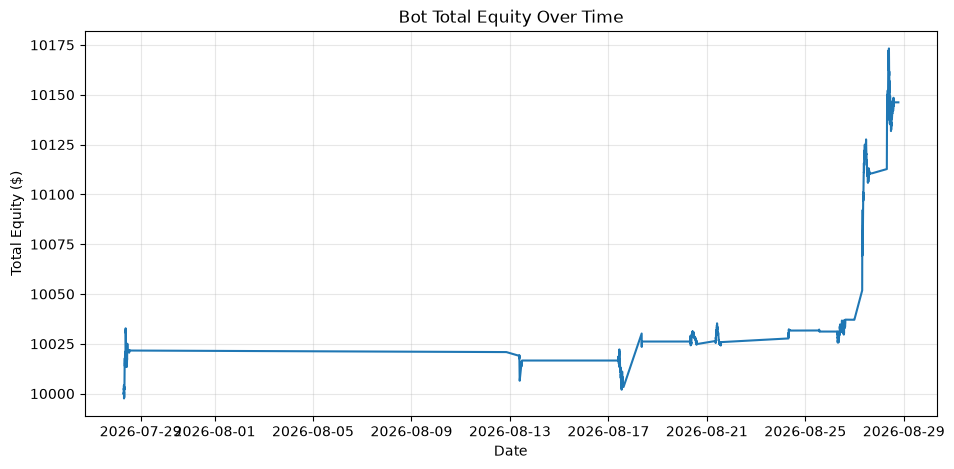

In [ ]:
import matplotlib.pyplot as plt

plot_df = equity_df.sort_values("datetime_col").copy()

plt.figure(figsize=(11, 5))
plt.plot(plot_df["datetime_col"], plot_df["equity"])
plt.title("Bot Total Equity Over Time")
plt.xlabel("Date")
plt.ylabel("Total Equity ($)")
plt.grid(True, alpha=0.3)
plt.show()

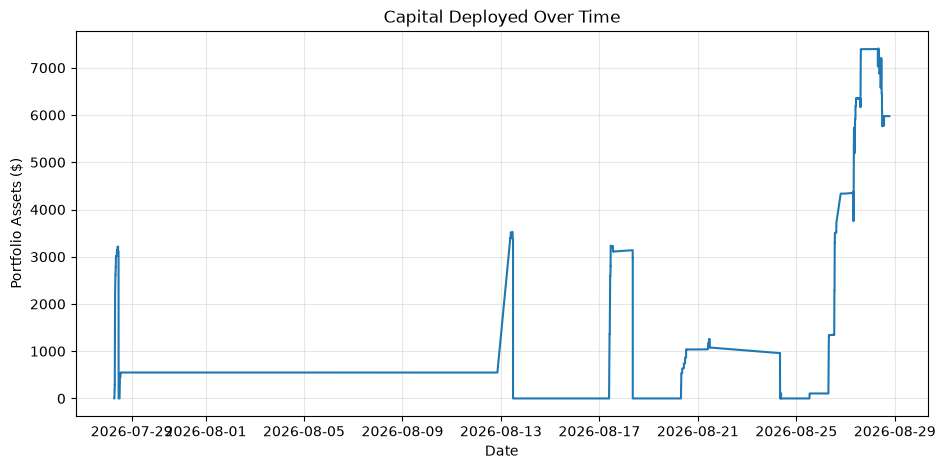

In [ ]:
plt.figure(figsize=(11, 5))
plt.plot(plot_df["datetime_col"], plot_df["portfolio_assets"])
plt.title("Capital Deployed Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Assets ($)")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    "Test": ["Manual Test", "Current Logged Test", "Combined"],
    "Daily Return on Deployed Capital": [
        manual_daily_return_on_deployed,
        daily_return_on_deployed_capital,
        combined_daily_return_on_deployed,
    ],
    "Annualized Capital-Efficiency Extrapolation (Simple)": [
        manual_annual_simple,
        annual_simple,
        combined_annual_simple,
    ],
    "Annualized Capital-Efficiency Extrapolation (Compound)": [
        manual_annual_compound,
        annual_compound,
        combined_annual_compound,
    ],
})

display(Markdown("## Performance Comparison"))
display(
    comparison_df.assign(
        **{
            "Daily Return on Deployed Capital": comparison_df["Daily Return on Deployed Capital"].map(format_pct),
            "Annualized Capital-Efficiency Extrapolation (Simple)": comparison_df["Annualized Capital-Efficiency Extrapolation (Simple)"].map(format_pct),
            "Annualized Capital-Efficiency Extrapolation (Compound)": comparison_df["Annualized Capital-Efficiency Extrapolation (Compound)"].map(format_pct),
        }
    )
)

## Performance Comparison

,Test,Daily Return on Deployed Capital,Annualized Simple Return,Annualized Compound Return
0,Manual Test,0.32%,81.84%,126.39%
1,Current Logged Test,0.50%,126.24%,252.26%
2,Combined,0.42%,105.32%,186.05%


In [ ]:
import yfinance as yf

tkr = yf.Ticker("MSFT")

print(tkr.history()["Close"])

Date
2026-07-29 00:00:00-04:00   389.8062
2026-07-30 00:00:00-04:00   450.2524
2026-07-31 00:00:00-04:00   463.8468
2026-08-03 00:00:00-04:00   486.7337
2026-08-04 00:00:00-04:00   491.8840
2026-08-05 00:00:00-04:00   486.5441
2026-08-06 00:00:00-04:00   498.9207
2026-08-07 00:00:00-04:00   499.0505
2026-08-10 00:00:00-04:00   505.1091
2026-08-11 00:00:00-04:00   502.8633
2026-08-12 00:00:00-04:00   491.5047
2026-08-13 00:00:00-04:00   495.9464
2026-08-14 00:00:00-04:00   494.4691
2026-08-17 00:00:00-04:00   479.4474
2026-08-18 00:00:00-04:00   480.7250
2026-08-19 00:00:00-04:00   483.4000
2026-08-20 00:00:00-04:00   481.1500
2026-08-21 00:00:00-04:00   483.2400
2026-08-24 00:00:00-04:00   487.3100
2026-08-25 00:00:00-04:00   491.7100
2026-08-26 00:00:00-04:00   496.3700
2026-08-27 00:00:00-04:00   505.0600
2026-08-28 00:00:00-04:00   513.5300
Name: Close, dtype: float64


In [ ]:
data = yf.download("AAPL", period="5d")
print(data)

[*********************100%***********************]  1 of 1 completed

Price         Close     High      Low     Open    Volume
Ticker         AAPL     AAPL     AAPL     AAPL      AAPL
Date                                                    
2026-08-24 310.3400 313.3600 309.9700 311.4700  34673600
2026-08-25 309.9000 313.5900 308.2100 310.7900  25869800
2026-08-26 313.4500 315.4300 308.8000 310.3000  34024500
2026-08-27 314.5800 315.4000 309.4000 310.5500  32419200
2026-08-28 319.7000 322.3700 315.4504 317.0880  38500185


: 